# Step 1: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    make_scorer
)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
df = pd.read_csv('/content/Employee Attrition.csv')

In [ ]:
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


# Step 2: Dataset Verification

In [ ]:
print("Dataset Verification")
print("=" * 60)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nAll Dataset Columns:")
print(df.columns.tolist())

Dataset Verification
Number of Rows: 59598
Number of Columns: 24

All Dataset Columns:
['Employee ID', 'Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition', 'Attrition']


# Step 3: Feature and Target Separation

In [ ]:
X = df.drop(columns=['Employee ID', 'Attrition'])
y = df['Attrition']

print("Feature and Target Separation")
print("=" * 60)

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTarget Values:")
print(y.unique())

Feature and Target Separation
Feature Shape: (59598, 22)
Target Shape : (59598,)

Feature Columns:
['Age', 'Gender', 'Years at Company', 'Job Role', 'Monthly Income', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Number of Promotions', 'Overtime', 'Distance from Home', 'Education Level', 'Marital Status', 'Number of Dependents', 'Job Level', 'Company Size', 'Company Tenure', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Target Values:
['Stayed' 'Left']


# Step 4: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Train-Test Split Completed")
print("=" * 60)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape :", X_test.shape)
print("Training Target Shape :", y_train.shape)
print("Testing Target Shape  :", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTesting Target Distribution:")
print(y_test.value_counts())

Train-Test Split Completed
Training Feature Shape: (47678, 22)
Testing Feature Shape : (11920, 22)
Training Target Shape : (47678,)
Testing Target Shape  : (11920,)

Training Target Distribution:
Attrition
Stayed    25008
Left      22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
Stayed    6252
Left      5668
Name: count, dtype: int64


# Step 5: Identify Numerical and Categorical Features

In [ ]:
numerical_features_xgb = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features_xgb = X_train.select_dtypes(include=['object']).columns.tolist()

print("Numerical and Categorical Features")
print("=" * 60)

print("\nNumerical Features:")
print(numerical_features_xgb)
print("\nNumber of Numerical Features:", len(numerical_features_xgb))

print("\nCategorical Features:")
print(categorical_features_xgb)
print("\nNumber of Categorical Features:", len(categorical_features_xgb))

Numerical and Categorical Features

Numerical Features:
['Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']

Number of Numerical Features: 7

Categorical Features:
['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']

Number of Categorical Features: 15


# Step 6: Preprocessing Pipeline

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features_xgb),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features_xgb)
    ]
)

print("XGBoost Preprocessing Pipeline Created Successfully")
print("=" * 60)

print("Numerical Features:", len(numerical_features_xgb))
print("Categorical Features:", len(categorical_features_xgb))

XGBoost Preprocessing Pipeline Created Successfully
Numerical Features: 7
Categorical Features: 15


# Step 7: Baseline XGBoost Pipeline

In [ ]:
baseline_xgb_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor_xgb),
        ('xgb', XGBClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42,
            n_jobs=-1,
            eval_metric='logloss'
        ))
    ]
)

print("Baseline XGBoost Pipeline Created Successfully")
print("=" * 60)

print("Model: XGBoost Classifier")
print("Number of Trees: 100")
print("Learning Rate: 0.1")
print("Maximum Depth: 3")
print("Random State: 42")

Baseline XGBoost Pipeline Created Successfully
Model: XGBoost Classifier
Number of Trees: 100
Learning Rate: 0.1
Maximum Depth: 3
Random State: 42


# Step 8: Encode Target Variable

In [ ]:
y_train_xgb = y_train.map({
    'Stayed': 0,
    'Left': 1
})

y_test_xgb = y_test.map({
    'Stayed': 0,
    'Left': 1
})

print("Target Encoding Completed")
print("=" * 60)

print("\nOriginal Target Classes:")
print(y_train.unique())

print("\nEncoded Target Classes:")
print(y_train_xgb.unique())

print("\nTraining Target Distribution:")
print(y_train_xgb.value_counts())

print("\nTesting Target Distribution:")
print(y_test_xgb.value_counts())

Target Encoding Completed

Original Target Classes:
['Stayed' 'Left']

Encoded Target Classes:
[0 1]

Training Target Distribution:
Attrition
0    25008
1    22670
Name: count, dtype: int64

Testing Target Distribution:
Attrition
0    6252
1    5668
Name: count, dtype: int64


# Step 9: Train Baseline Model

In [ ]:
baseline_xgb_pipeline.fit(X_train, y_train_xgb)

print("Baseline XGBoost Model Trained Successfully")

Baseline XGBoost Model Trained Successfully


# Step 10: Baseline Predictions

In [ ]:
y_pred_baseline_xgb = baseline_xgb_pipeline.predict(X_test)

print("Baseline XGBoost Predictions Generated Successfully")
print("=" * 60)

print("Number of Predictions:", len(y_pred_baseline_xgb))

print("\nFirst 20 Predictions (Encoded):")
print(y_pred_baseline_xgb[:20])

Baseline XGBoost Predictions Generated Successfully
Number of Predictions: 11920

First 20 Predictions (Encoded):
[1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0]


# Step 11: Baseline Model Evaluation Performance

In [ ]:
accuracy_baseline_xgb = accuracy_score(y_test_xgb, y_pred_baseline_xgb)
precision_baseline_xgb = precision_score(y_test_xgb, y_pred_baseline_xgb, pos_label=1)
recall_baseline_xgb = recall_score(y_test_xgb, y_pred_baseline_xgb, pos_label=1)
f1_baseline_xgb = f1_score(y_test_xgb, y_pred_baseline_xgb, pos_label=1)

print("Baseline XGBoost Performance")
print("=" * 50)
print(f"Accuracy : {accuracy_baseline_xgb:.4f}")
print(f"Precision: {precision_baseline_xgb:.4f}")
print(f"Recall   : {recall_baseline_xgb:.4f}")
print(f"F1 Score : {f1_baseline_xgb:.4f}")

Baseline XGBoost Performance
Accuracy : 0.7590
Precision: 0.7483
Recall   : 0.7431
F1 Score : 0.7457


# Step 12: Baseline Confusion Matrix

In [ ]:
cm_baseline_xgb = confusion_matrix(
    y_test_xgb,
    y_pred_baseline_xgb,
    labels=[0, 1]
)

print("Baseline XGBoost Confusion Matrix")
print("=" * 60)
print(cm_baseline_xgb)
print("\nTotal samples in confusion matrix:", cm_baseline_xgb.sum())

Baseline XGBoost Confusion Matrix
[[4835 1417]
 [1456 4212]]

Total samples in confusion matrix: 11920


# Step 13: Baseline Classification Report

In [ ]:
print("Classification Report - Baseline XGBoost")
print("=" * 60)
print(
    classification_report(
        y_test_xgb,
        y_pred_baseline_xgb,
        labels=[0, 1],
        target_names=['Stayed', 'Left']
    )
)

Classification Report - Baseline XGBoost
              precision    recall  f1-score   support

      Stayed       0.77      0.77      0.77      6252
        Left       0.75      0.74      0.75      5668

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



# Step 14: Baseline ROC-AUC

In [ ]:
y_proba_baseline_xgb = baseline_xgb_pipeline.predict_proba(X_test)[:, 1]
roc_auc_baseline_xgb = roc_auc_score(y_test_xgb, y_proba_baseline_xgb)

print("Baseline XGBoost ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_baseline_xgb:.4f}")

Baseline XGBoost ROC-AUC
ROC-AUC : 0.8471


# Step 15: Hyperparameter Tuning

In [ ]:
xgb_param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__max_depth': [2, 3]
}

print("XGBoost Parameter Grid")
print("=" * 60)
print(xgb_param_grid)

XGBoost Parameter Grid
{'xgb__n_estimators': [100, 200], 'xgb__learning_rate': [0.05, 0.1], 'xgb__max_depth': [2, 3]}


# Step 16: Custom F1 Scorer

In [ ]:
f1_left_scorer_xgb = make_scorer(
    f1_score,
    pos_label=1
)

print("Custom F1 Scorer Created Successfully")
print("=" * 60)
print("Positive Class: Left (1)")
print("Scoring Metric: F1 Score")

Custom F1 Scorer Created Successfully
Positive Class: Left (1)
Scoring Metric: F1 Score


# Step 17: Hyperparameter Tuning

In [ ]:
xgb_grid_search = GridSearchCV(
    estimator = baseline_xgb_pipeline,
    param_grid = xgb_param_grid,
    scoring = f1_left_scorer_xgb,
    cv = 3,
    n_jobs = -1,
    verbose = 1
)

xgb_grid_search.fit(
    X_train,
    y_train_xgb
)

print("XGBoost Hyperparameter Tuning Completed")
print("=" * 60)

print("Best Parameters:")
print(xgb_grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{xgb_grid_search.best_score_:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
XGBoost Hyperparameter Tuning Completed
Best Parameters:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}

Best Cross-Validation F1 Score:
0.7439


# Step 18: Tuned Model

In [ ]:
tuned_xgb_model = xgb_grid_search.best_estimator_

print("Tuned XGBoost Model Ready")
print("=" * 60)
print("Best Parameters:")
print(xgb_grid_search.best_params_)

Tuned XGBoost Model Ready
Best Parameters:
{'xgb__learning_rate': 0.1, 'xgb__max_depth': 3, 'xgb__n_estimators': 200}


# Step 19: Tuned Predictions

In [ ]:
y_pred_tuned_xgb = tuned_xgb_model.predict(X_test)

print("Tuned XGBoost Predictions Generated Successfully")
print("=" * 60)
print("Number of Predictions:", len(y_pred_tuned_xgb))
print("\nFirst 20 Predictions (Encoded):")
print(y_pred_tuned_xgb[:20])

Tuned XGBoost Predictions Generated Successfully
Number of Predictions: 11920

First 20 Predictions (Encoded):
[1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0]


# Step 20: Tuned MOdel Evaluation Performance

In [ ]:
accuracy_tuned_xgb = accuracy_score(y_test_xgb, y_pred_tuned_xgb)
precision_tuned_xgb = precision_score(y_test_xgb, y_pred_tuned_xgb, pos_label=1)
recall_tuned_xgb = recall_score(y_test_xgb, y_pred_tuned_xgb, pos_label=1)
f1_tuned_xgb = f1_score(y_test_xgb, y_pred_tuned_xgb, pos_label=1)

print("Tuned XGBoost Performance")
print("=" * 50)
print(f"Accuracy : {accuracy_tuned_xgb:.4f}")
print(f"Precision: {precision_tuned_xgb:.4f}")
print(f"Recall   : {recall_tuned_xgb:.4f}")
print(f"F1 Score : {f1_tuned_xgb:.4f}")

Tuned XGBoost Performance
Accuracy : 0.7616
Precision: 0.7514
Recall   : 0.7451
F1 Score : 0.7482


# Step 21: Tuned Confusion Matrix

In [ ]:
cm_tuned_xgb = confusion_matrix(
    y_test_xgb,
    y_pred_tuned_xgb,
    labels=[0, 1]
)

print("Tuned XGBoost Confusion Matrix")
print("=" * 60)
print(cm_tuned_xgb)
print("\nTotal samples in confusion matrix:", cm_tuned_xgb.sum())

Tuned XGBoost Confusion Matrix
[[4855 1397]
 [1445 4223]]

Total samples in confusion matrix: 11920


# Step 22: Tuned Classification Report

In [ ]:
print("Classification Report - Tuned XGBoost")
print("=" * 60)
print(
    classification_report(
        y_test_xgb,
        y_pred_tuned_xgb,
        labels=[0, 1],
        target_names=['Stayed', 'Left']
    )
)

Classification Report - Tuned XGBoost
              precision    recall  f1-score   support

      Stayed       0.77      0.78      0.77      6252
        Left       0.75      0.75      0.75      5668

    accuracy                           0.76     11920
   macro avg       0.76      0.76      0.76     11920
weighted avg       0.76      0.76      0.76     11920



# Step 23: Tuned ROC-AUC

In [ ]:
y_proba_tuned_xgb = tuned_xgb_model.predict_proba(X_test)[:, 1]
roc_auc_tuned_xgb = roc_auc_score(y_test_xgb, y_proba_tuned_xgb)

print("Tuned XGBoost ROC-AUC")
print("=" * 50)
print(f"ROC-AUC : {roc_auc_tuned_xgb:.4f}")

Tuned XGBoost ROC-AUC
ROC-AUC : 0.8494


# Step 24: Feature Importance

feature importance shows how much the model uses a feature, it does not by itself prove that the feature causes employee attrition.

In [ ]:
# Get the preprocessing step
preprocessor_fitted_xgb = tuned_xgb_model.named_steps['preprocessor']

# Get the XGBoost model
xgb_model_fitted = tuned_xgb_model.named_steps['xgb']

# Get transformed feature names
feature_names_xgb = preprocessor_fitted_xgb.get_feature_names_out()

# Get feature importance
importance_values_xgb = xgb_model_fitted.feature_importances_

# Create feature importance DataFrame
xgb_feature_importance = pd.DataFrame({
    'Feature': feature_names_xgb,
    'Importance': importance_values_xgb
})

# Sort by importance
xgb_feature_importance = xgb_feature_importance.sort_values(
    by='Importance',
    ascending=False
).reset_index(drop=True)

print("XGBoost Feature Importance")
print("=" * 60)

print("\nTop 15 XGBoost Features:")
print("=" * 60)

print(xgb_feature_importance.head(15).to_string(index=False))

XGBoost Feature Importance

Top 15 XGBoost Features:
                          Feature  Importance
               cat__Job Level_Mid    0.196256
       cat__Marital Status_Single    0.087026
             cat__Job Level_Entry    0.074028
            cat__Job Level_Senior    0.071984
              cat__Remote Work_No    0.055141
      cat__Work-Life Balance_Fair    0.042554
      cat__Work-Life Balance_Poor    0.040722
     cat__Company Reputation_Good    0.033569
      cat__Work-Life Balance_Good    0.032465
        num__Number of Promotions    0.032460
               cat__Gender_Female    0.031441
         cat__Education Level_PhD    0.030237
        num__Number of Dependents    0.027932
cat__Company Reputation_Excellent    0.023396
 cat__Work-Life Balance_Excellent    0.020053


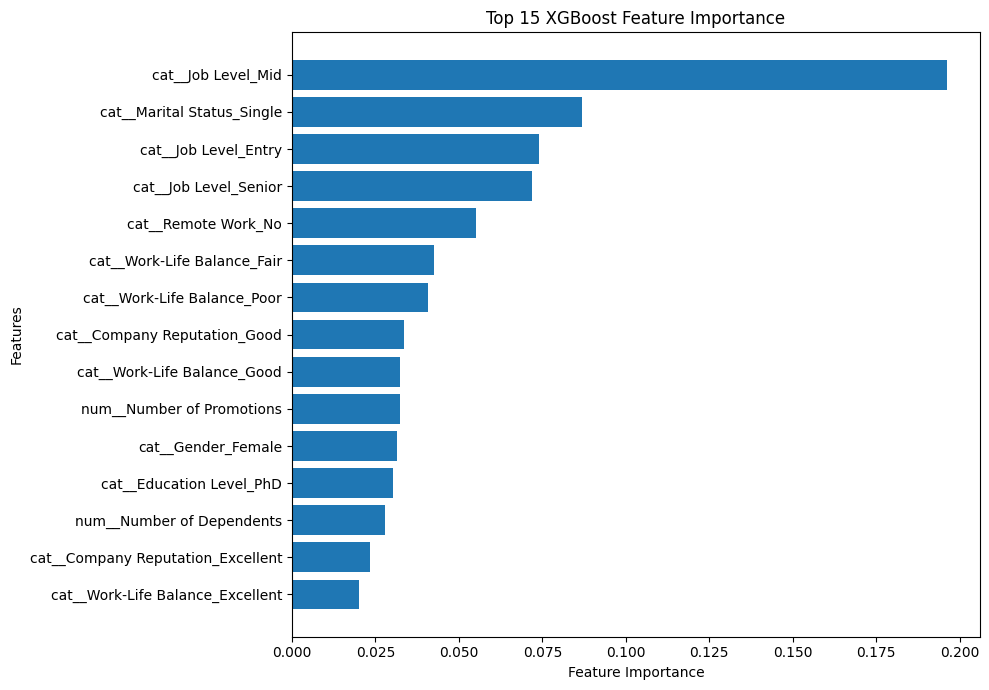

In [ ]:
top_15_xgb = xgb_feature_importance.head(15).sort_values(
    by='Importance',
    ascending=True
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_15_xgb['Feature'],
    top_15_xgb['Importance']
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 XGBoost Feature Importance")
plt.tight_layout()
plt.show()

# Step 25: Baseline vs Tuned Comparison

In [ ]:
xgb_comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision (Left)',
        'Recall (Left)',
        'F1 Score (Left)',
        'ROC-AUC'
    ],
    'Baseline': [
        accuracy_baseline_xgb,
        precision_baseline_xgb,
        recall_baseline_xgb,
        f1_baseline_xgb,
        roc_auc_baseline_xgb
    ],
    'Tuned': [
        accuracy_tuned_xgb,
        precision_tuned_xgb,
        recall_tuned_xgb,
        f1_tuned_xgb,
        roc_auc_tuned_xgb
    ]
})

print("Baseline vs Tuned XGBoost")
print("=" * 70)
print(xgb_comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Baseline vs Tuned XGBoost
          Metric  Baseline  Tuned
        Accuracy    0.7590 0.7616
Precision (Left)    0.7483 0.7514
   Recall (Left)    0.7431 0.7451
 F1 Score (Left)    0.7457 0.7482
         ROC-AUC    0.8471 0.8494


# Step 26: Save Tuned Model

In [ ]:
import joblib

xgb_model_filename = "Employee_Attrition_XGBoost_Model.pkl"
joblib.dump(
    tuned_xgb_model,
    xgb_model_filename
)

print("XGBoost Model Saved Successfully")
print("=" * 60)
print("File Name:", xgb_model_filename)

XGBoost Model Saved Successfully
File Name: Employee_Attrition_XGBoost_Model.pkl


# Step 27: Load Saved Model

In [ ]:
import joblib

loaded_xgb_model = joblib.load("Employee_Attrition_XGBoost_Model.pkl")

print("XGBoost Model Loaded Successfully")
print("=" * 60)
print("Loaded Model: Employee_Attrition_XGBoost_Model.pkl")

XGBoost Model Loaded Successfully
Loaded Model: Employee_Attrition_XGBoost_Model.pkl


# Step 28: Loaded Model Verification

In [ ]:
y_pred_loaded_xgb = loaded_xgb_model.predict(X_test)

print("Loaded XGBoost Model Verification")
print("=" * 60)
print("Number of Predictions:", len(y_pred_loaded_xgb))
print("\nFirst 20 Predictions:")
print(y_pred_loaded_xgb[:20])

# Compare predictions
same_predictions_xgb = np.array_equal(
    y_pred_tuned_xgb,
    y_pred_loaded_xgb
)

print("\nPrediction Comparison")
print("=" * 60)

if same_predictions_xgb:
    print("Tuned and Loaded Model Predictions: SAME")
    print("Model Verification: PASSED")
else:
    print("Tuned and Loaded Model Predictions: DIFFERENT")
    print("Model Verification: FAILED")

Loaded XGBoost Model Verification
Number of Predictions: 11920

First 20 Predictions:
[1 0 1 1 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0]

Prediction Comparison
Tuned and Loaded Model Predictions: SAME
Model Verification: PASSED
